# Formula 1 Race Intelligence

## Exploratory Data Analysis (EDA) - Laps

### Objetivo

Este notebook tiene como objetivo realizar el análisis exploratorio del dataset `laps_raw.csv`, que contiene información detallada de las vueltas registradas durante las sesiones analizadas.

Este dataset es uno de los más importantes del proyecto, ya que permite estudiar el rendimiento de pilotos y equipos a través de variables como:

- Duración de vuelta.
- Número de vuelta.
- Sectores.
- Stints.
- Sesión.
- Piloto.
- Circuito.
- Temporada.

El análisis permitirá identificar valores nulos, duplicados, posibles outliers y patrones relevantes en los tiempos de vuelta.

## Importación de librerías

Se importan la librería necesarias para la manipulación, análisis y visualización de los datos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Carga de los datasets

A continuación se carga el dataset de las vueltas.

In [2]:
laps = pd.read_csv("../data/raw/laps_raw.csv")

print("Dataset cargado correctamente")
laps.head()

Dataset cargado correctamente


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,season,country_name,location_name,session_name,session_type,date_start_session,date_end_session
0,1229,9468,55,1,NaN,NaN,47.556,25.067,210.0,231.0,True,NaN,"[2064, 2064, 2064, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2051, 2051, 2051, 2051]",102.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
1,1229,9468,16,1,2024-03-01T16:00:16.716000+00:00,NaN,45.475,27.582,219.0,240.0,True,NaN,"[2064, 2064, 2064, 2049, 2049, 2051, 2051, 204...","[2049, 2049, 2051, 2051, 2051, 2051, 2049, 205...","[2051, 2051, 2051, 2049, 2049, 2049, 2051]",73.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
2,1229,9468,31,1,2024-03-01T16:00:22.110000+00:00,NaN,48.580,25.377,179.0,218.0,True,NaN,"[2064, 2064, 2064, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",61.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
3,1229,9468,10,1,2024-03-01T16:00:24.082000+00:00,NaN,46.947,31.307,197.0,214.0,True,NaN,"[2064, 2064, 2064, 2049, 2049, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",72.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
4,1229,9468,55,2,2024-03-01T16:02:03.464000+00:00,29.76,38.878,22.570,238.0,273.0,False,91.208,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2051, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2051, 2051, 2049, 2051, 2048]",311.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00


## Inspección inicial

En esta sección se revisa la estructura general del dataset: número de filas, columnas, tipos de datos, valores nulos y duplicados.

In [3]:
print("Shape:", laps.shape)

Shape: (86008, 23)


In [4]:
laps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86008 entries, 0 to 86007
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   meeting_key         86008 non-null  int64  
 1   session_key         86008 non-null  int64  
 2   driver_number       86008 non-null  int64  
 3   lap_number          86008 non-null  int64  
 4   date_start          85891 non-null  object 
 5   duration_sector_1   80698 non-null  float64
 6   duration_sector_2   85585 non-null  float64
 7   duration_sector_3   84339 non-null  float64
 8   i1_speed            75639 non-null  float64
 9   i2_speed            84675 non-null  float64
 10  is_pit_out_lap      86008 non-null  bool   
 11  lap_duration        83775 non-null  float64
 12  segments_sector_1   85920 non-null  object 
 13  segments_sector_2   85907 non-null  object 
 14  segments_sector_3   85880 non-null  object 
 15  st_speed            80141 non-null  float64
 16  seas

In [6]:
print(laps.duplicated().sum())

0


In [10]:
laps.describe()

,meeting_key,session_key,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,lap_duration,st_speed,season
count,86008.000000,86008.000000,86008.000000,86008.000000,80698.000000,85585.000000,84339.000000,75639.000000,84675.000000,83775.000000,80141.000000,86008.000000
mean,1256.856444,9942.173682,29.629651,24.135360,29.041704,35.476564,29.257451,246.918018,242.403696,113.963312,287.096205,2024.686913
std,16.652860,539.452570,24.549118,18.409016,8.013863,8.352507,8.963975,48.976315,49.490343,114.678414,46.722621,0.687495
min,1229.000000,9468.000000,1.000000,1.000000,16.251000,16.915000,15.941000,31.000000,26.000000,63.971000,25.000000,2024.000000
25%,1242.000000,9582.000000,11.000000,9.000000,24.284000,29.460000,23.132000,212.000000,203.000000,81.774000,279.000000,2024.000000
50%,1257.000000,9854.000000,22.000000,19.000000,28.600500,34.758000,27.333000,254.000000,254.000000,92.606000,301.000000,2025.000000
75%,1271.000000,9975.000000,44.000000,38.000000,32.091000,41.122000,33.413000,286.000000,280.000000,101.641000,314.000000,2025.000000
max,1286.000000,11299.000000,87.000000,78.000000,121.725000,90.308000,99.438000,359.000000,347.000000,2264.580000,364.000000,2026.000000


In [47]:
laps.isnull().sum().sort_values(ascending=False)

i1_speed              10369
st_speed               5867
duration_sector_1      5310
lap_duration           2233
duration_sector_3      1669
i2_speed               1333
duration_sector_2       423
segments_sector_3       128
date_start              117
segments_sector_2       101
segments_sector_1        88
lap_number                0
meeting_key               0
session_key               0
driver_number             0
is_pit_out_lap            0
season                    0
country_name              0
location_name             0
session_name              0
session_type              0
date_start_session        0
date_end_session          0
dtype: int64

### Interpretación de los valores nulos

El análisis de valores nulos muestra que la mayoría de las columnas del dataset presentan una completitud muy elevada, siendo únicamente algunas variables relacionadas con sectores y velocidades las que concentran la mayor parte de los registros faltantes.

Las columnas contienen valores nulos debido a la naturaleza de determinadas vueltas registradas. Estas situaciones suelen corresponder a vueltas de salida de boxes, vueltas de entrada a boxes, intentos abortados durante clasificación, incidencias en pista o registros incompletos proporcionados por la fuente de datos.

La variable 'date_start' presenta únicamente un número muy reducido de valores nulos, por lo que no supone un problema significativo para el análisis.

Dado que los valores faltantes se explican por situaciones reales de competición y no por errores de extracción o almacenamiento, se conservarán inicialmente para futuras fases de limpieza y análisis, donde se evaluará su tratamiento en función de los objetivos.

## Distribución de tiempos de vuelta

Se analiza la distribución general de la variable lap_duration, que representa la duración total de cada vuelta registrada.
Este análisis permite identificar el rango habitual de tiempos de vuelta, la presencia de valores extremos y posibles registros asociados a vueltas anómalas, como entradas o salidas de boxes, vueltas abortadas o incidentes en pista.

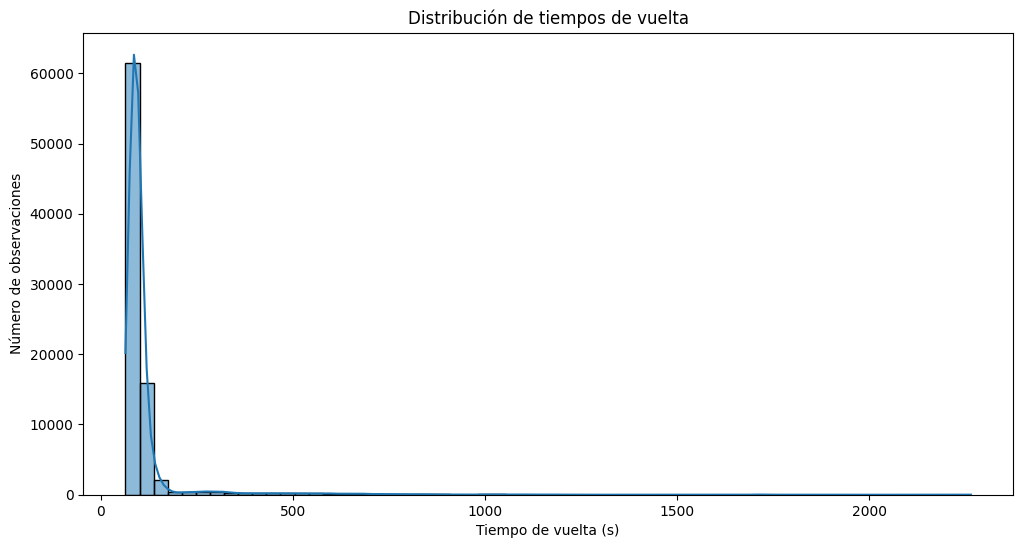

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(laps["lap_duration"].dropna(),bins=60,kde=True)

plt.title("Distribución de tiempos de vuelta")
plt.xlabel("Tiempo de vuelta (s)")
plt.ylabel("Número de observaciones")
plt.show()

### Interpretación

La distribución de tiempos de vuelta muestra una concentración principal de observaciones en un rango relativamente definido, correspondiente a vueltas competitivas realizadas en condiciones normales de sesión.
Se observan valores más elevados que se alejan del núcleo principal de la distribución. Estos registros pueden corresponder a vueltas de entrada o salida de boxes, tráfico, incidentes, banderas amarillas o intentos abortados, especialmente en sesiones de clasificación.
Valores no deben interpretarse necesariamente como errores, sino como situaciones reales de competición que deberán tratarse con cuidado en fases posteriores de limpieza y análisis.

## Tiempo medio de vuelta por tipo de sesión

Comparación  del tiempo medio de vuelta entre los distintos tipos de sesión.
Permite observar diferencias de rendimiento entre sesiones de carrera, clasificación y sprint, teniendo en cuenta que cada una responde a objetivos deportivos diferentes.

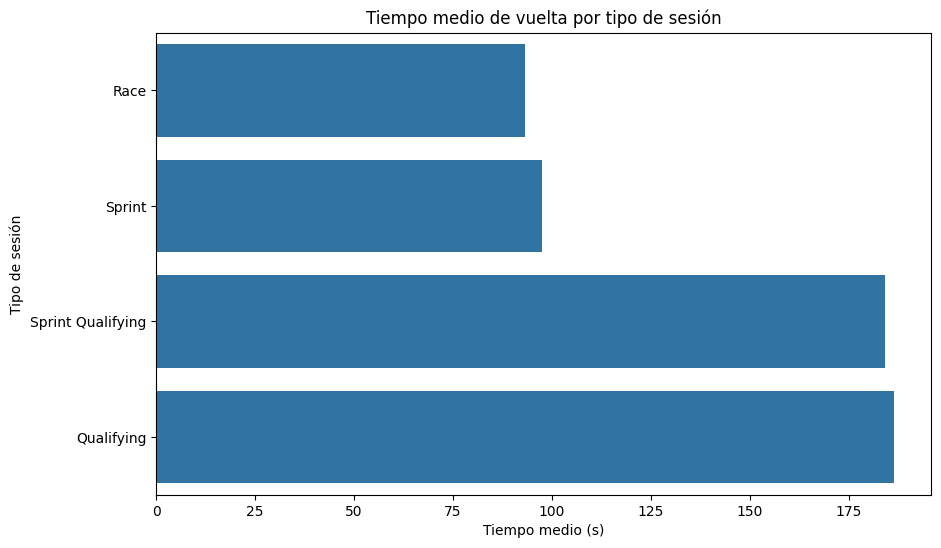

In [39]:
lap_session = (laps.groupby("session_name")["lap_duration"].mean().sort_values())

plt.figure(figsize=(10,6))

sns.barplot(
    x=lap_session.values,
    y=lap_session.index
)

plt.title("Tiempo medio de vuelta por tipo de sesión")
plt.xlabel("Tiempo medio (s)")
plt.ylabel("Tipo de sesión")
plt.show()

### Interpretación

El gráfico muestra diferencias significativas en el tiempo medio de vuelta entre los distintos tipos de sesión. Sin embargo, los resultados obtenidos no coinciden completamente con el comportamiento esperado en Fórmula 1, donde normalmente las sesiones de clasificación suelen registrar los tiempos más rápidos.

Las sesiones de carrera y sprint presentan tiempos medios cercanos a los 95 segundos, mientras que las sesiones de clasificación y sprint qualifying superan los 180 segundos de media. Esta diferencia sugiere la presencia de valores atípicos o vueltas no competitivas que están influyendo de forma considerable en el cálculo de la media.

Posible explicación, es que existen vueltas de preparación, entrada o salida de boxes, intentos abortados, interrupciones por bandera roja o registros incompletos.

## Tiempo medio de vuelta(fuera de boxes) por tipo de sesión
Esto eliminará una parte de las vueltas que salen desde pit lane, ya que no son vueltas lanzadas y habrá que calentar neumático o mirar el comportamiento del monoplaza.

In [41]:
laps_validas = laps[laps["is_pit_out_lap"] == False]

print(laps.groupby("session_name")["lap_duration"].mean())
print(laps_validas.groupby("session_name")["lap_duration"].mean())

session_name
Qualifying           186.449743
Race                  93.081598
Sprint                97.586743
Sprint Qualifying    184.231304
Name: lap_duration, dtype: float64
session_name
Qualifying           114.010157
Race                  91.522765
Sprint                92.787587
Sprint Qualifying    115.344816
Name: lap_duration, dtype: float64


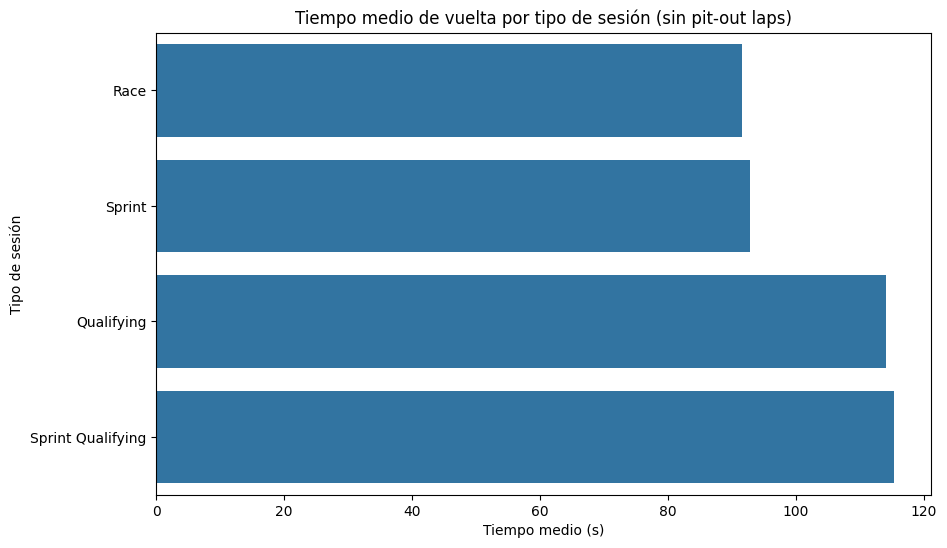

In [42]:
lap_session = (laps_validas.groupby("session_name")["lap_duration"].mean().sort_values())

plt.figure(figsize=(10,6))

sns.barplot(
    x=lap_session.values,
    y=lap_session.index
)

plt.title("Tiempo medio de vuelta por tipo de sesión (sin pit-out laps)")
plt.xlabel("Tiempo medio (s)")
plt.ylabel("Tipo de sesión")
plt.show()

### Mediana por sesion

Mientras que las sesiones de carrera presentan una distribución relativamente compacta, las sesiones de clasificación muestran una diferencia considerable, indicando una mayor variabilidad en los tiempos registrados.

Por este motivo, la media resulta una métrica poco representativa para comparar el rendimiento entre sesiones. En análisis posteriores será preferible utilizar medidas más robustas, como la mediana, o aplicar filtros específicos para aislar únicamente las vueltas competitivas.

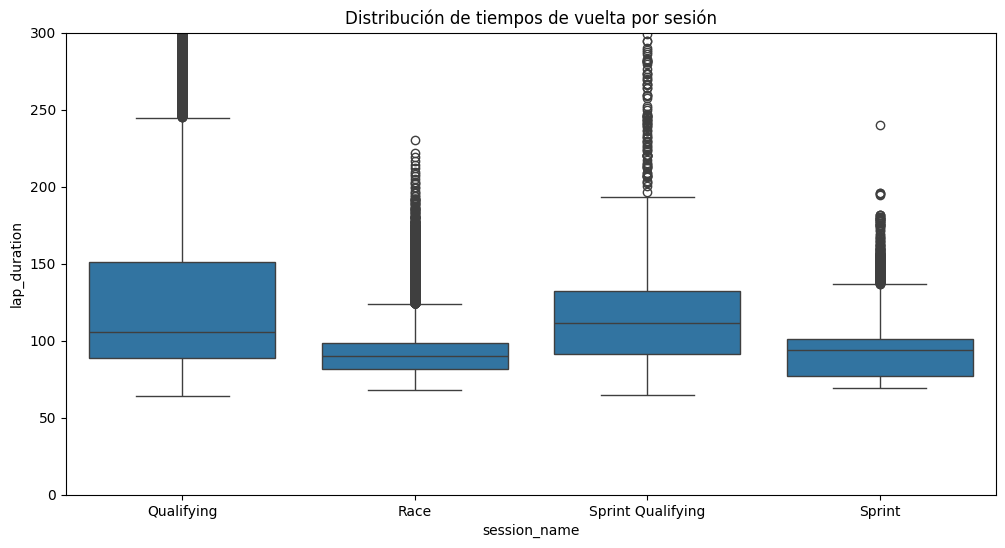

In [43]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=laps,
    x="session_name",
    y="lap_duration"
)
##Mejora de visualizacion para Y a 300s, por encima no es representativo
plt.ylim(0,300)

plt.title("Distribución de tiempos de vuelta por sesión")

plt.show()

## Distribución de velocidades por punto de medición

En esta sección se analizan las velocidades registradas en los distintos puntos de medición.
Este análisis permite comparar la distribución de velocidades en diferentes zonas del circuito e identificar diferencias entre puntos de medición, dispersión de valores y posibles registros atípicos.

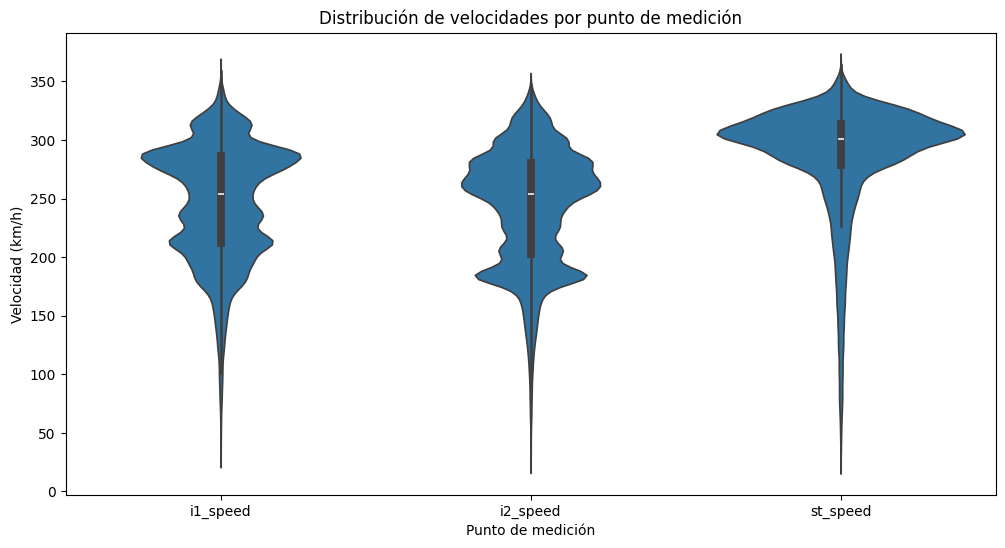

In [24]:
speed_data = laps[
    ["i1_speed", "i2_speed", "st_speed"]
].melt(
    var_name="speed_type",
    value_name="speed"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    data=speed_data,
    x="speed_type",
    y="speed"
)

plt.title("Distribución de velocidades por punto de medición")
plt.xlabel("Punto de medición")
plt.ylabel("Velocidad (km/h)")

plt.show()

### Interpretación

Se observa que 'st_speed' concentra las velocidades más elevadas, lo que sugiere que este punto de medición suele estar asociado a zonas rápidas del circuito, como rectas principales o zonas de alta velocidad.

Las variables i1 e i2, presentan distribuciones similares, aunque con una mayor variabilidad. Donde los valores bajos pueden corresponder a vueltas lentas, pasos por boxes, tráfico, etc.

En conjunto, las velocidades registradas son coherentes con el comportamiento esperado de un monoplaza de Fórmula 1 y aportan información útil para futuros análisis de rendimiento.

## Vueltas registradas por temporada

Se analiza la cantidad de vueltas registradas por temporada para comprobar la representatividad temporal del dataset.

Aquí hay un paso importante porque la temporada 2026 todavía no está completa, por lo que se espera una menor cantidad de registros respecto a 2024 y 2025.

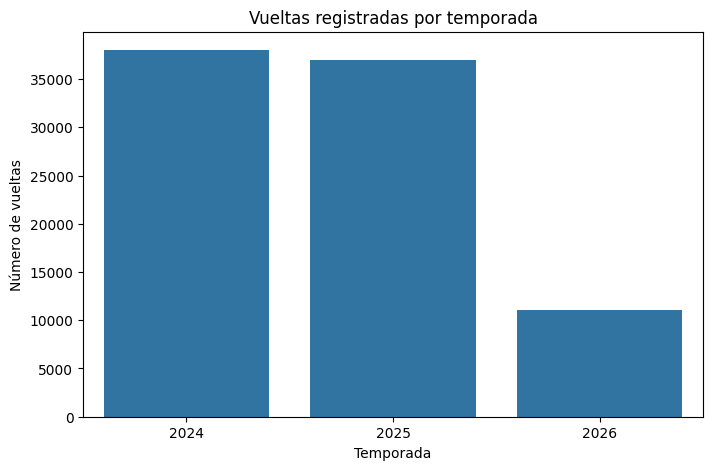

In [27]:
season_laps = laps["season"].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(
    x=season_laps.index,
    y=season_laps.values
)

plt.title("Vueltas registradas por temporada")
plt.xlabel("Temporada")
plt.ylabel("Número de vueltas")
plt.show()

### Interpretación

La distribución por temporada permite comprobar que las temporadas 2024 y 2025 presentan un volumen de datos más elevado y equilibrado, mientras que 2026 cuenta con menos registros al tratarse de una temporada parcial.

## Circuitos cubiertos por temporada
Se comprueba el número de circuitos distintos por temporada para detectar posibles huecos.
Esto permite verificar si 2024 y 2025 cubren el calendario completo y si 2026 (temporada parcial) sigue el orden cronológico esperado de carreras disputadas hasta la fecha.

In [49]:
print(laps.groupby("season")["location_name"].nunique())

laps.groupby(["season","location_name"])["lap_number"].count().reset_index().pivot(
    index="location_name", columns="season", values="lap_number"
)

season
2024    24
2025    24
2026     6
Name: location_name, dtype: int64


season,2024,2025,2026
location_name,,,
Austin,1927.0,1876.0,NaN
Baku,1286.0,968.0,NaN
Barcelona,1567.0,1451.0,NaN
Budapest,1690.0,1633.0,NaN
Imola,1525.0,1489.0,NaN
Jeddah,1218.0,1189.0,NaN
Las Vegas,1287.0,1263.0,NaN
Lusail,1981.0,2105.0,NaN
Marina Bay,1455.0,1527.0,NaN


## Distribución de tiempos por sector

Se analiza la duración de los tres sectores de cada vuelta.

Permite comparar la variabilidad de los sectores y detectar diferencias estructurales entre partes del circuito.

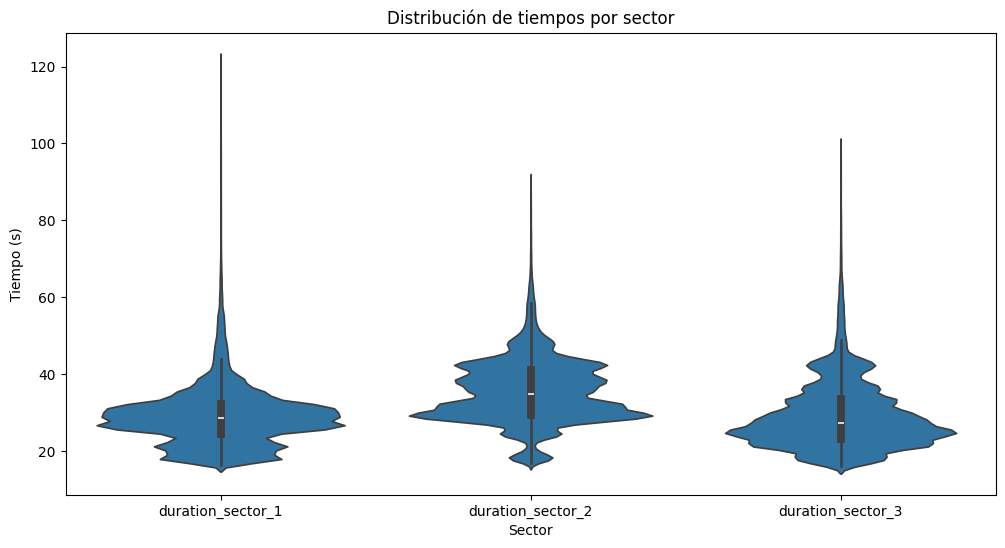

In [31]:
sector_data = laps[
    [
        "duration_sector_1",
        "duration_sector_2",
        "duration_sector_3"
    ]
].melt(
    var_name="sector",
    value_name="time"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    data=sector_data,
    x="sector",
    y="time"
)

plt.title("Distribución de tiempos por sector")
plt.xlabel("Sector")
plt.ylabel("Tiempo (s)")
plt.show()

### Interpretación

El Sector 2 presenta, en términos generales, los tiempos más elevados y una mayor dispersión, lo que sugiere una mayor complejidad en comparación con los otros sectores.

Por su parte, los Sectores 1 y 3 presentan distribuciones más compactas y concentradas, indicando una mayor homogeneidad en los tiempos registrados.

Asimismo, se observan algunos valores extremos en los tres sectores. Estos registros pueden estar asociados a incidencias durante la vuelta, tráfico, entradas o salidas de boxes, interrupciones de sesión u otras situaciones excepcionales propias de la competición.

## Correlación entre variables de rendimiento

Se analiza la correlación entre las principales variables numéricas relacionadas con el rendimiento de una vuelta.
Para ello se incluyen:
- duración total de la vuelta.
- duración de cada sector.
- velocidades registradas en distintos puntos de medición.

El objetivo es identificar qué variables están más relacionadas entre sí y qué indicadores pueden tener mayor influencia sobre el tiempo total de vuelta.

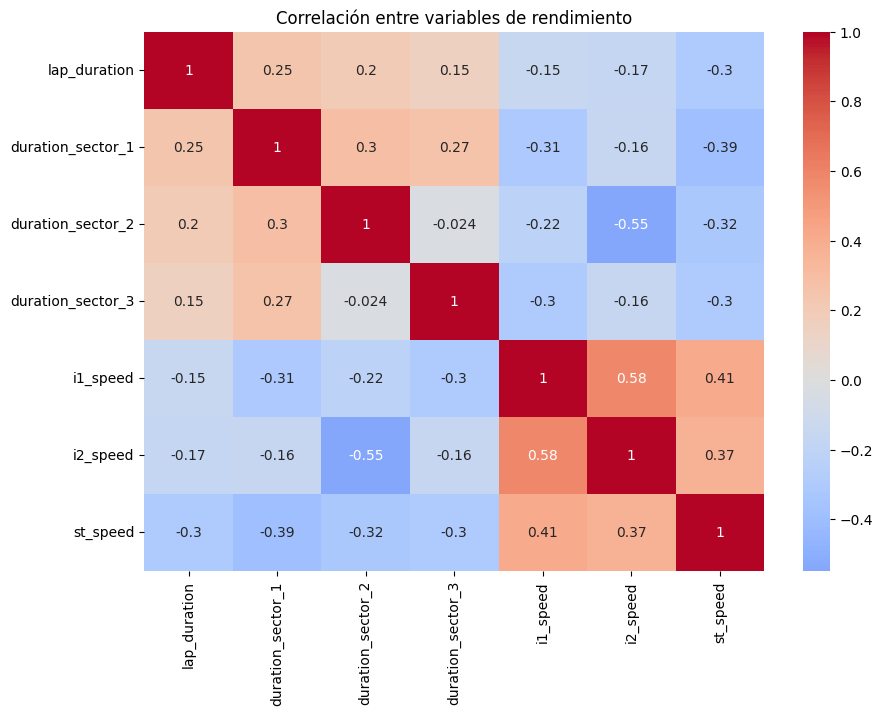

In [34]:
variables_rendimiento = [
    "lap_duration",
    "duration_sector_1",
    "duration_sector_2",
    "duration_sector_3",
    "i1_speed",
    "i2_speed",
    "st_speed"
]

corr_mat = laps[variables_rendimiento].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_mat,
    annot=True,
    cmap="coolwarm",
    center=0,
)

plt.title("Correlación entre variables de rendimiento")
plt.show()

### Interpretación

La matriz de correlación muestra que las relaciones entre las variables de rendimiento son moderadas, aunque permiten identificar varios patrones relevantes.

En primer lugar, el tiempo total de vuelta presenta correlaciones positivas con los tres sectores, ya que un aumento en el tiempo empleado en cualquier sector contribuye directamente a incrementar la duración total de la vuelta. 
Las velocidades registradas presentan correlaciones negativas con 'lap_duration', eso indica que velocidades más elevadas suelen estar asociadas a tiempos de vuelta menores.

Destaca la correlación negativa entre 'duration_sector_2' e i2_speed con un -0.55, lo que sugiere que este punto de medición tiene una influencia significativa sobre el tiempo empleado en el segundo sector.
A medida que aumenta la velocidad registrada en dicho punto, el tiempo del sector tiende a reducirse.

Correlacion positiva entre sí, sobre todo en 'i1_speed' e 'i2_speed, esto indica que los monoplazas que alcanzan velocidades elevadas en una zona del circuito suelen mantener un comportamiento similar en otros puntos de medición.

# Conclusiones

El análisis exploratorio me ha permitido comprender la estructura general y detectar varios aspectos importantes para futuras fases del proyecto.
En primer lugar, el dataset presenta una buena calidad general, sin registros duplicados y con un número reducido de valores nulos concentrados en sectores y velocidades. Los valores faltantes se ven asociados a situaciones reales de competición, como vueltas de entrada o salida de boxes, intentos abortados o incidencias durante las sesiones.
En el estudio de los tiempos de vuelta, se identifica una cantidad significativa de valores atípicos, especialmente en las sesiones de clasificación. Esto afecta en métricas como la media, por lo que se ha determinado que la mediana resulta una medida más representativa para describir el comportamiento habitual de las vueltas registradas.

En el análisis de los sectores se ha mostrado diferencias apreciables entre las distintas partes del circuito, siendo el segundo sector quien presenta una mayor dispersión de tiempos.

En el análisis de correlaciones se puede identificar relaciones coherentes entre las variables de rendimiento. Los tiempos de sector presentan una relación positiva con la duración total de la vuelta, mientras que las velocidades muestran correlaciones negativas con el tiempo de vuelta, indicando que velocidades más elevadas suelen estar asociadas a mejores rendimientos.

En conjunto, el análisis permite validar la calidad del dataset, identificar posibles problemas que deberán abordarse durante la fase de limpieza y obtener una primera visión de los factores que influyen en el rendimiento de los monoplazas.